<a href="https://colab.research.google.com/github/scientificbroker/business-analytics-para-startups/blob/main/Code%20Colabs/M1_EDA_Startups_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1 — EDA: Análisis Exploratorio de Datos para Startups LATAM

**Caso de uso:** SaaS B2B de gestión contable para PYMEs latinoamericanas  
*(Inspirado en ContaAzul — Brasil, Alegra — Colombia, Bind — México)*

---

## Objetivos del módulo

1. Cargar y explorar la estructura de un dataset de clientes SaaS
2. Evaluar la calidad de los datos (nulos, duplicados, tipos)
3. Analizar distribuciones de variables clave (MRR, engagement, NPS)
4. Explorar la composición por país, plan e industria
5. Identificar correlaciones y señales predictoras de churn
6. Detectar outliers con métodos IQR y Z-score
7. Derivar conclusiones accionables para el equipo de negocio

---

**Datos que necesitas** (o usa el dataset simulado incluido):  
- Tabla de clientes: ID, país, plan, MRR, fecha_inicio, churn  
- Tabla de uso: logins/mes, features_usadas, tickets_soporte  
- Mínimo recomendado: **200+ registros**

> **Repositorio:** [business-analytics-para-startups](https://github.com/scientificbroker/business-analytics-para-startups)

## 0. Instalación de dependencias

Ejecuta esta celda solo si estás en **Google Colab** o en un entorno nuevo.

In [ ]:
# Instala las dependencias necesarias (ejecuta solo una vez en Google Colab)
# En un entorno local con pandas/numpy/matplotlib/seaborn/scipy/scikit-learn ya instalados,
# puedes omitir esta celda.
%pip install pandas numpy matplotlib seaborn scipy scikit-learn -q


Note: you may need to restart the kernel to use updated packages.


## 1. Configuración de parámetros

Modifica estos valores para adaptar el análisis a tu negocio.

In [5]:
# ════════════════════════════════════════════════
# PARÁMETROS CONFIGURABLES — edita según tu caso
# ════════════════════════════════════════════════

N_CLIENTES   = 800        # número de registros a simular (o tamaño de tu CSV real)
RANDOM_SEED  = 42         # semilla para reproducibilidad

# Planes y precios MRR en USD (ajusta a tu modelo de precios)
MRR_BASE = {'Starter': 49, 'Growth': 149, 'Enterprise': 499}

# Países y sus pesos relativos en tu base de clientes
PAISES       = ['México', 'Brasil', 'Argentina', 'Colombia', 'Chile']
PESOS_PAIS   = [0.25, 0.30, 0.20, 0.15, 0.10]

# Para cargar datos reales, descomenta:
# RUTA_CSV = 'tu_archivo.csv'
# df = pd.read_csv(RUTA_CSV)

## 2. Importaciones y configuración visual

In [6]:
%matplotlib inline
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual consistente con el branding del curso
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
PALETTE = ['#2ECC71', '#E74C3C', '#3498DB', '#F39C12', '#9B59B6']
sns.set_palette(PALETTE)
plt.rcParams.update({'figure.figsize': (12, 7), 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
np.random.seed(RANDOM_SEED)

print('Modulo 1: EDA — Startup SaaS B2B LATAM')
print('Similar a: ContaAzul (Brasil), Alegra (Colombia), Bind (Mexico)')


Modulo 1: EDA — Startup SaaS B2B LATAM
Similar a: ContaAzul (Brasil), Alegra (Colombia), Bind (Mexico)


## 3. Generación del dataset simulado

Este bloque simula una base de clientes realista para un SaaS B2B en etapa Seed/Serie A.  
Si tienes datos reales, reemplaza con `df = pd.read_csv('tu_archivo.csv')`.

**Variables incluidas:**
| Variable | Descripción |
|---|---|
| `mrr_usd` | Monthly Recurring Revenue por cliente |
| `meses_activo` | Tiempo de vida del cliente |
| `logins_mes` | Logins promedio por mes (proxy de engagement) |
| `features_usadas` | Cantidad de funcionalidades activadas |
| `nps_score` | Net Promoter Score (0-10) |
| `churn` | 1 = canceló, 0 = activo |

In [7]:
N = N_CLIENTES

planes     = ['Starter', 'Growth', 'Enterprise']
pesos_plan = [0.50, 0.35, 0.15]
industrias = ['Comercio', 'Servicios', 'Manufactura', 'Construcción', 'Salud']

data = {
    'cliente_id':       [f'CLI-{i:04d}' for i in range(1, N+1)],
    'pais':             np.random.choice(PAISES, N, p=PESOS_PAIS),
    'plan':             np.random.choice(planes, N, p=pesos_plan),
    'industria':        np.random.choice(industrias, N),
    'meses_activo':     np.random.exponential(scale=14, size=N).astype(int) + 1,
    'empleados_pyme':   np.random.choice([1, 5, 15, 50, 100], N, p=[0.3, 0.3, 0.2, 0.15, 0.05]),
    'logins_mes':       np.random.poisson(lam=18, size=N),
    'features_usadas':  np.random.randint(1, 12, N),
    'tickets_soporte':  np.random.poisson(lam=1.8, size=N),
    'nps_score':        np.random.choice(range(0, 11), N, p=[0.03]*3 + [0.06]*4 + [0.13]*2 + [0.205, 0.205]),
}

df = pd.DataFrame(data)

# MRR con variación realista por plan (+/- 20%)
df['mrr_usd'] = df['plan'].map(MRR_BASE) * np.random.uniform(0.8, 1.2, N)
df['mrr_usd'] = df['mrr_usd'].round(2)

# Churn: más probable en Starter, pocos meses activos y bajo engagement
prob_churn = (
    (df['plan'] == 'Starter').astype(float) * 0.20 +
    (df['meses_activo'] < 3).astype(float) * 0.25 +
    (df['logins_mes'] < 5).astype(float) * 0.30 +
    (df['features_usadas'] < 3).astype(float) * 0.15
)
prob_churn = (prob_churn / prob_churn.max()).clip(0.05, 0.85)
df['churn'] = (np.random.random(N) < prob_churn).astype(int)

# Introducir valores nulos realistas (5-8%)
for col, pct in [('nps_score', 0.08), ('empleados_pyme', 0.05), ('tickets_soporte', 0.03)]:
    mask = np.random.random(N) < pct
    df.loc[mask, col] = np.nan

# Outliers controlados (errores de entrada de datos — comunes en LATAM)
df.loc[np.random.choice(N, 8, replace=False), 'mrr_usd'] *= 15
df.loc[np.random.choice(N, 5, replace=False), 'logins_mes'] = 0

print(f'Dataset creado: {df.shape[0]} clientes x {df.shape[1]} variables')
print(f'Tasa de churn global: {df["churn"].mean():.1%}')
print(f'MRR Total: ${df["mrr_usd"].sum():,.0f} USD/mes')

Dataset creado: 800 clientes x 12 variables
Tasa de churn global: 27.4%
MRR Total: $132,443 USD/mes


## 4. Primera vista y resumen estadístico

Antes de cualquier análisis, siempre explora la estructura del dataset.  
Presta atención a: rangos de valores, tipos de datos y si los números tienen sentido de negocio.

In [8]:
print('Primeras 5 filas:')
display(df.head())

print('\nResumen estadístico (variables numéricas):')
display(df.describe().round(2))

print('\nTipos de datos por columna:')
print(df.dtypes.to_string())

Primeras 5 filas:


,cliente_id,pais,plan,industria,meses_activo,empleados_pyme,logins_mes,features_usadas,tickets_soporte,nps_score,mrr_usd,churn
0,CLI-0001,Brasil,Growth,Manufactura,12,1.0,20,3,0.0,0.0,150.65,0
1,CLI-0002,Chile,Starter,Comercio,16,5.0,16,2,0.0,4.0,49.34,1
2,CLI-0003,Argentina,Growth,Comercio,5,1.0,23,10,1.0,10.0,174.29,0
3,CLI-0004,Argentina,Growth,Manufactura,4,5.0,14,7,0.0,NaN,151.93,0
4,CLI-0005,México,Starter,Comercio,10,1.0,22,9,1.0,8.0,50.63,0



Resumen estadístico (variables numéricas):


,meses_activo,empleados_pyme,logins_mes,features_usadas,tickets_soporte,nps_score,mrr_usd,churn
count,800.00,766.00,800.00,800.00,775.00,737.00,800.00,800.00
mean,15.08,16.41,17.46,6.06,1.74,6.98,165.55,0.27
std,14.69,22.48,4.24,3.16,1.23,2.70,201.56,0.45
min,1.00,1.00,0.00,1.00,0.00,0.00,39.20,0.00
25%,5.00,1.00,15.00,3.00,1.00,5.00,48.74,0.00
50%,11.00,5.00,17.00,6.00,2.00,8.00,120.90,0.00
75%,21.00,15.00,20.00,9.00,3.00,9.00,165.88,1.00
max,115.00,100.00,30.00,11.00,7.00,10.00,2525.25,1.00



Tipos de datos por columna:
cliente_id          object
pais                object
plan                object
industria           object
meses_activo         int64
empleados_pyme     float64
logins_mes           int64
features_usadas      int64
tickets_soporte    float64
nps_score          float64
mrr_usd            float64
churn                int64


## 5. Calidad de datos

Un análisis con datos sucios produce conclusiones incorrectas.  
Revisamos: **valores nulos**, **duplicados** y **tipos incorrectos**.

**Regla práctica LATAM:** en datasets de PYMEs es común encontrar 5-15% de nulos en campos opcionales (NPS, encuestas, tamaño de empresa). No es un error — es un patrón de comportamiento.

In [9]:
# Análisis de valores faltantes
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
calidad_df = pd.DataFrame({'nulos': nulos, 'pct_nulo': pct_nulos})
calidad_df = calidad_df[calidad_df['nulos'] > 0].sort_values('pct_nulo', ascending=False)

if len(calidad_df) > 0:
    print('Variables con valores faltantes:')
    display(calidad_df)
    print('\nAccion sugerida:')
    print('  nps_score (encuesta opcional) → imputar con mediana')
    print('  empleados_pyme → imputar con moda o valor por pais')
else:
    print('Sin valores faltantes.')

print(f'\nRegistros duplicados: {df.duplicated().sum()}')
print(f'IDs únicos de clientes: {df["cliente_id"].nunique()}')

# Aplicar limpieza
df_clean = df.copy()
df_clean['nps_score'] = df_clean['nps_score'].fillna(df_clean['nps_score'].median())
df_clean['empleados_pyme'] = df_clean['empleados_pyme'].fillna(df_clean['empleados_pyme'].mode()[0])
df_clean['tickets_soporte'] = df_clean['tickets_soporte'].fillna(0)

print(f'\nDataset limpio: {df_clean.isnull().sum().sum()} nulos restantes.')

Variables con valores faltantes:


,nulos,pct_nulo
nps_score,63,7.88
empleados_pyme,34,4.25
tickets_soporte,25,3.12



Accion sugerida:
  nps_score (encuesta opcional) → imputar con mediana
  empleados_pyme → imputar con moda o valor por pais

Registros duplicados: 0
IDs únicos de clientes: 800

Dataset limpio: 0 nulos restantes.


## 6. Distribuciones de variables numéricas

1.   Elemento de la lista
2.   Elemento de la lista



Los histogramas revelan la **forma** de los datos:  
- **Simétrico (campana):** datos bien distribuidos  
- **Cola a la derecha (skew > 0):** pocos valores muy altos (típico en MRR y gasto)  
- **Cola a la izquierda (skew < 0):** concentración en valores altos (ej. NPS en productos exitosos)

Un skewness mayor a 1 en variables numéricas generalmente requiere transformación logarítmica antes de entrenar modelos de ML.

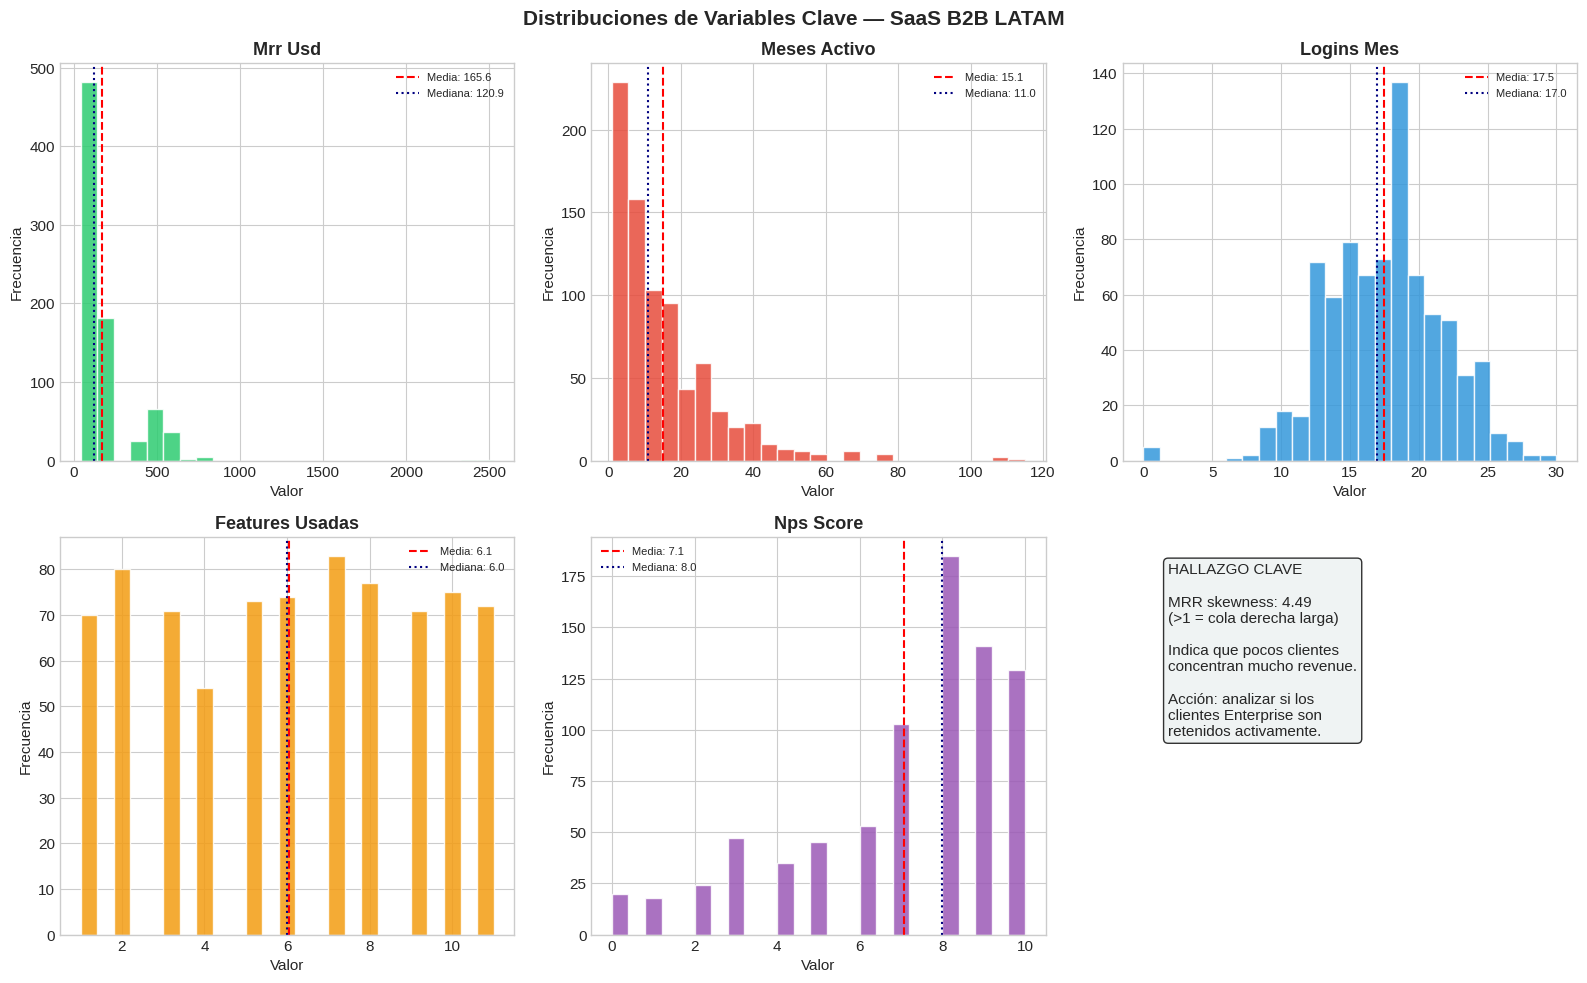


Asimetría (skewness) — valores >1 sugieren log-transform antes de ML:
  mrr_usd                skew=+4.49  [ALERTA: considera log-transform]
  meses_activo           skew=+2.21  [ALERTA: considera log-transform]
  logins_mes             skew=-0.29  [OK: distribución aceptable]
  features_usadas        skew=-0.05  [OK: distribución aceptable]
  nps_score              skew=-1.01  [ALERTA: considera log-transform]


In [10]:
num_cols = ['mrr_usd', 'meses_activo', 'logins_mes', 'features_usadas', 'nps_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones de Variables Clave — SaaS B2B LATAM', fontsize=15, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    data_col = df_clean[col].dropna()
    ax.hist(data_col, bins=25, edgecolor='white', alpha=0.85, color=PALETTE[i % len(PALETTE)])
    ax.axvline(data_col.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {data_col.mean():.1f}')
    ax.axvline(data_col.median(), color='navy', linestyle=':', linewidth=1.5, label=f'Mediana: {data_col.median():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Panel de hallazgo clave
axes[1][2].axis('off')
skew_mrr = df_clean['mrr_usd'].skew()
axes[1][2].text(0.1, 0.5,
    f'HALLAZGO CLAVE\n\n'
    f'MRR skewness: {skew_mrr:.2f}\n'
    f'(>1 = cola derecha larga)\n\n'
    f'Indica que pocos clientes\n'
    f'concentran mucho revenue.\n\n'
    f'Acción: analizar si los\n'
    f'clientes Enterprise son\n'
    f'retenidos activamente.',
    transform=axes[1][2].transAxes, fontsize=11,
    bbox=dict(boxstyle='round', facecolor='#ECF0F1', alpha=0.8))

plt.tight_layout()
plt.savefig('M1_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de asimetría
print('\nAsimetría (skewness) — valores >1 sugieren log-transform antes de ML:')
for col in num_cols:
    sk = df_clean[col].skew()
    flag = 'ALERTA: considera log-transform' if abs(sk) > 1 else 'OK: distribución aceptable'
    print(f'  {col:<22} skew={sk:+.2f}  [{flag}]')

## 7. Variables categóricas y churn por segmento

Las variables categóricas revelan la **composición** del negocio.  
La tabla de churn por plan es la pregunta que todo fundador se hace primero:  
**¿En qué plan cancelan más mis clientes?**

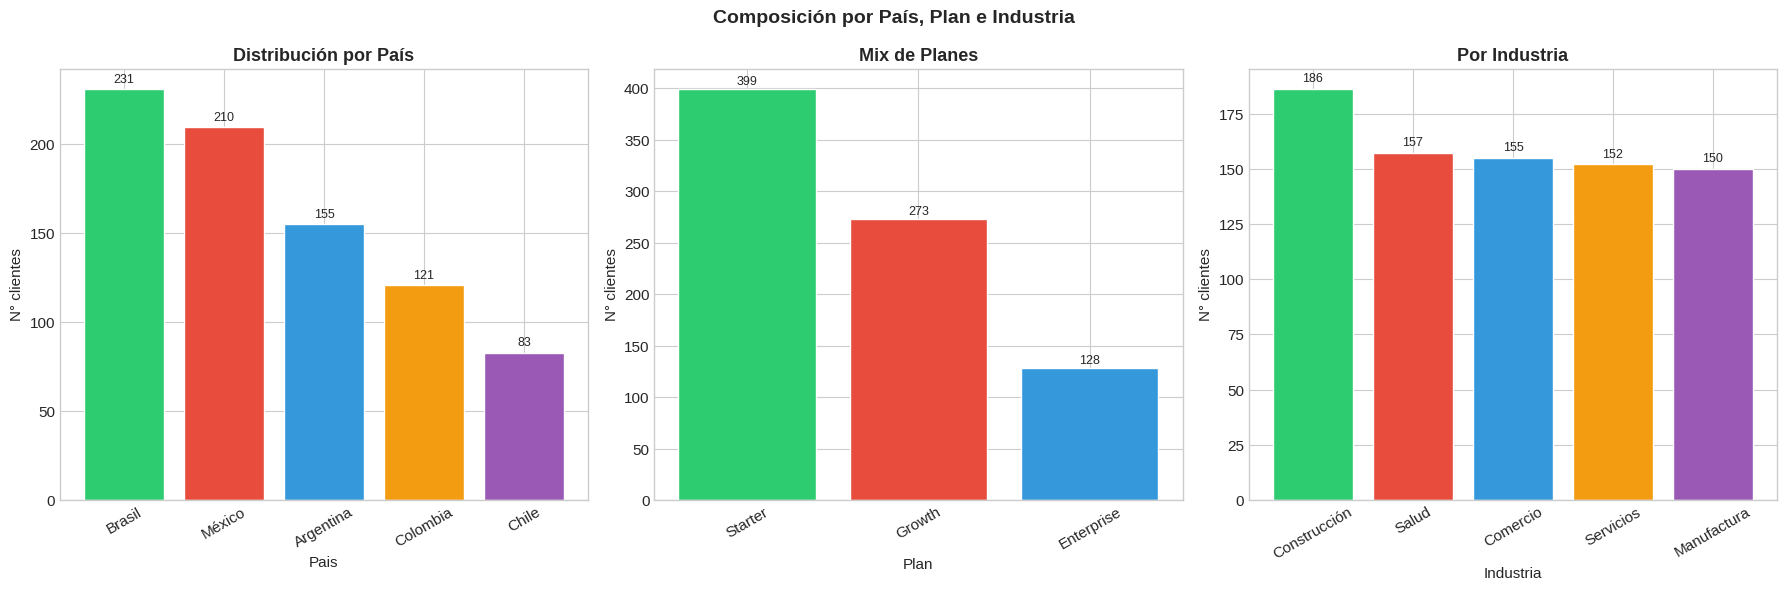


Tasa de churn por Plan:


,tasa_churn,n_clientes,tasa_churn_pct
plan,,,
Enterprise,0.172,128,17.2
Growth,0.099,273,9.9
Starter,0.426,399,42.6



Tasa de churn por País:


,churn_%
pais,
Chile,34.9
Colombia,33.9
México,26.7
Brasil,24.2
Argentina,23.9


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Composición por País, Plan e Industria', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes, ['pais', 'plan', 'industria'],
                          ['Distribución por País', 'Mix de Planes', 'Por Industria']):
    counts = df_clean[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=PALETTE[:len(counts)], edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col.title())
    ax.set_ylabel('N° clientes')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('M1_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

# Churn por plan
print('\nTasa de churn por Plan:')
churn_plan = df_clean.groupby('plan')['churn'].agg(['mean', 'count']).round(3)
churn_plan.columns = ['tasa_churn', 'n_clientes']
churn_plan['tasa_churn_pct'] = (churn_plan['tasa_churn'] * 100).round(1)
display(churn_plan)

print('\nTasa de churn por País:')
churn_pais = df_clean.groupby('pais')['churn'].mean().sort_values(ascending=False)
display((churn_pais * 100).round(1).rename('churn_%'))

## 8. Matriz de correlaciones

La correlación mide cuánto se mueven juntas dos variables (entre -1 y +1).  

**Cómo leerla para negocio:**
- **r cerca de -1 con churn:** esa variable *protege* contra la cancelación → reforzarla
- **r cerca de +1 con churn:** esa variable *aumenta* el riesgo → corregirla
- **r cerca de 0:** sin relación clara con churn

La diagonal siempre es 1 (una variable siempre correlaciona perfectamente consigo misma).

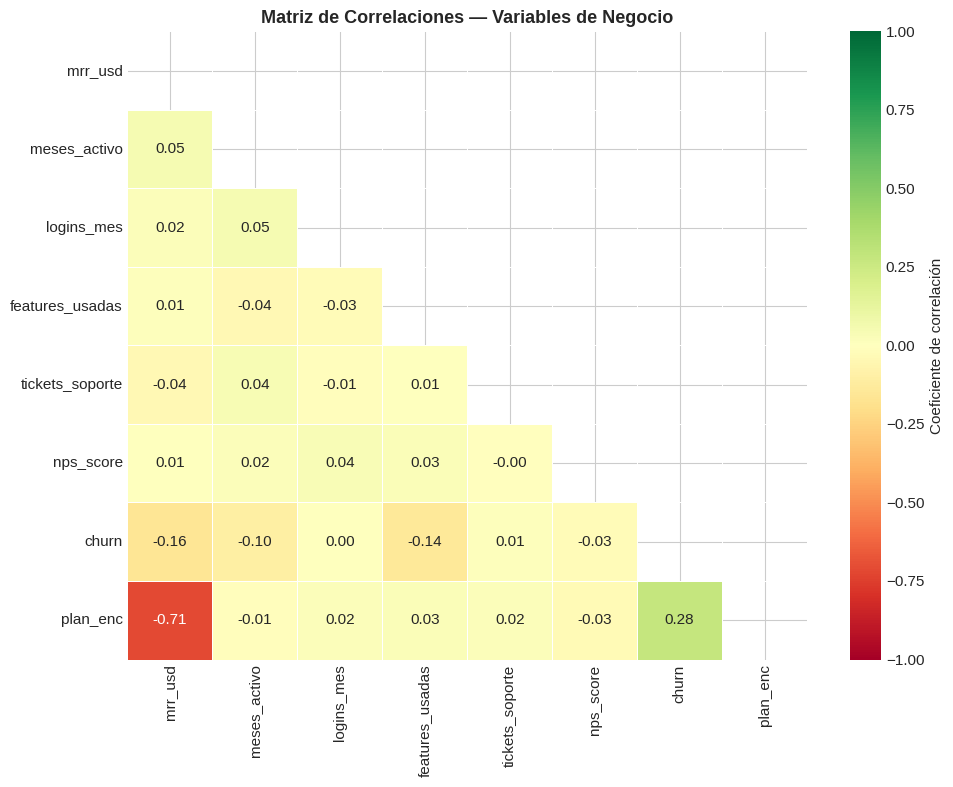


Correlaciones con CHURN (las variables que mejor predicen cancelación):
  plan_enc               r=+0.281  → AUMENTA riesgo
  mrr_usd                r=-0.157  → PROTEGE contra churn
  features_usadas        r=-0.142  → PROTEGE contra churn
  meses_activo           r=-0.104  → PROTEGE contra churn
  nps_score              r=-0.027  → sin relación clara
  tickets_soporte        r=+0.012  → sin relación clara
  logins_mes             r=+0.005  → sin relación clara


In [12]:
df_corr = df_clean.copy()
le = LabelEncoder()
for col in ['pais', 'plan', 'industria']:
    df_corr[col + '_enc'] = le.fit_transform(df_corr[col])

corr_cols = ['mrr_usd', 'meses_activo', 'logins_mes', 'features_usadas',
             'tickets_soporte', 'nps_score', 'churn', 'plan_enc']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de correlación'})
ax.set_title('Matriz de Correlaciones — Variables de Negocio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('M1_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelaciones con CHURN (las variables que mejor predicen cancelación):')
corr_churn = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)
for var, val in corr_churn.items():
    signo = 'PROTEGE contra churn' if val < -0.1 else ('AUMENTA riesgo' if val > 0.1 else 'sin relación clara')
    print(f'  {var:<22} r={val:+.3f}  → {signo}')

## 9. Detección de outliers

Los outliers pueden ser **errores** (datos de entrada incorrectos) o **señales valiosas** (cliente Enterprise real con MRR 10x mayor).  

Usamos dos métodos complementarios:
- **IQR (rango intercuartílico):** robusto a distribuciones asimétricas — ideal para MRR
- **Z-score:** asume distribución normal — mejor para NPS y logins

Análisis de outliers por variable numérica:
  mrr_usd                IQR: 136 outliers | Z-score:   5 outliers | rango válido: [-127, 342]
  logins_mes             IQR:  10 outliers | Z-score:   5 outliers | rango válido: [8, 28]
  meses_activo           IQR:  33 outliers | Z-score:  13 outliers | rango válido: [-19, 45]


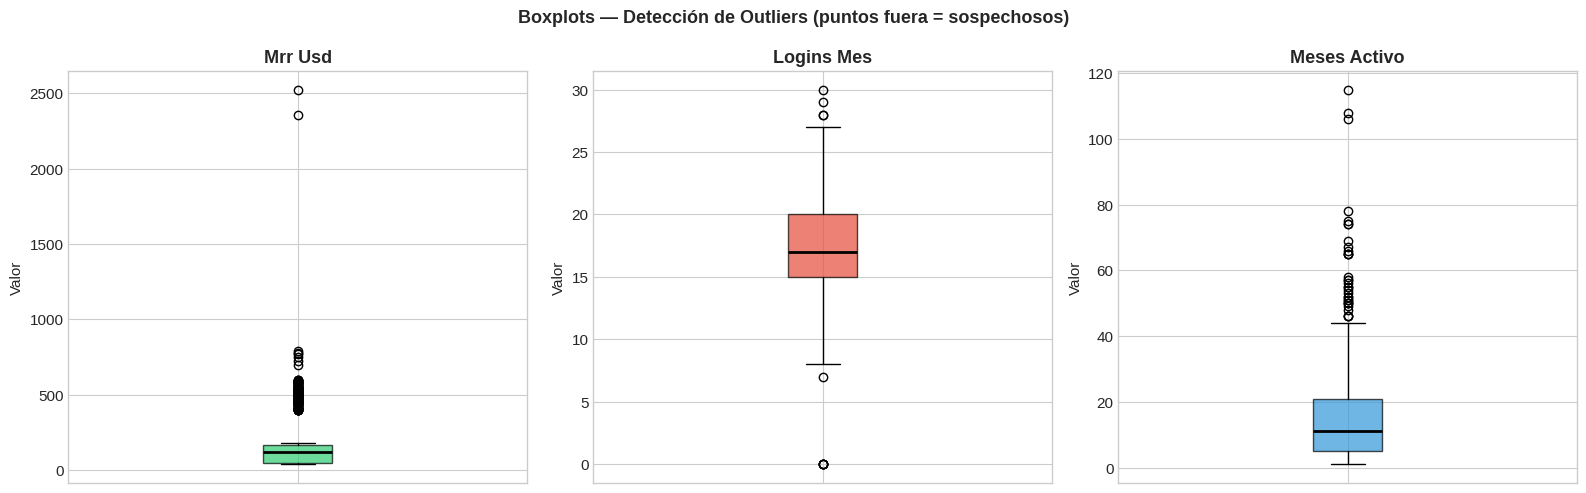

In [13]:
def detectar_outliers(series, nombre):
    """Detecta outliers con IQR y Z-score. Imprime resumen."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers_iqr = ((series < lim_inf) | (series > lim_sup)).sum()
    z_scores = np.abs(stats.zscore(series.dropna()))
    outliers_z = (z_scores > 3).sum()
    print(f'  {nombre:<22} IQR: {outliers_iqr:>3} outliers | Z-score: {outliers_z:>3} outliers | rango válido: [{lim_inf:.0f}, {lim_sup:.0f}]')
    return lim_inf, lim_sup

print('Análisis de outliers por variable numérica:')
for col in ['mrr_usd', 'logins_mes', 'meses_activo']:
    detectar_outliers(df_clean[col], col)

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplots — Detección de Outliers (puntos fuera = sospechosos)', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['mrr_usd', 'logins_mes', 'meses_activo'], PALETTE):
    bp = ax.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Valor')
    ax.set_xticklabels([''])

plt.tight_layout()
plt.savefig('M1_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusiones ejecutivas y próximos pasos

El EDA no termina con gráficos — termina con **decisiones de negocio**.

In [14]:
mrr_mediana    = df_clean['mrr_usd'].median()
churn_global   = df_clean['churn'].mean()
plan_mas_churn = churn_plan['tasa_churn_pct'].idxmax()
nps_prom       = df_clean['nps_score'].mean()

print('=' * 65)
print('CONCLUSIONES EJECUTIVAS — EDA SaaS B2B LATAM')
print('=' * 65)
print(f"""
HALLAZGOS CLAVE:

  1. MRR mediana: ${mrr_mediana:.0f}/mes.
     Los outliers de MRR son candidatos Enterprise: verificar si son
     clientes reales o errores de datos.

  2. Churn global {churn_global:.1%}: el plan '{plan_mas_churn}' concentra mayor
     riesgo de cancelación.
     Benchmark SaaS B2B LATAM: 8-15% anual.
     Si tu churn mensual supera 3%, hay un problema de product-market fit.

  3. NPS promedio {nps_prom:.1f}/10: la correlación negativa con churn confirma
     que mejorar la experiencia es la palanca de retención más directa.

  4. Features usadas es la señal de engagement más fuerte.
     Clientes que usan 3+ features raramente cancelan.
     → Activación rápida = prioridad #1.

  5. Brasil y México son los mercados con más clientes,
     pero revisa si la tasa de churn por país justifica marketing diferenciado.

ACCIÓN INMEDIATA:
  → Crear un Health Score = f(logins, features, nps) para monitoreo semanal.
  → Activar campaña de onboarding para clientes con <3 features en primeros 30 días.

PROXIMO MODULO RECOMENDADO:
  Si quieres PREDECIR qué clientes cancelarán → M2 (XGBoost Churn Prediction)
  Si quieres SEGMENTAR clientes por comportamiento → M4 (KMeans + RFM)
  Si quieres calcular cuánto vale cada cliente → M3 (LTV/CAC)
""")

CONCLUSIONES EJECUTIVAS — EDA SaaS B2B LATAM

HALLAZGOS CLAVE:

  1. MRR mediana: $121/mes.
     Los outliers de MRR son candidatos Enterprise: verificar si son
     clientes reales o errores de datos.

  2. Churn global 27.4%: el plan 'Starter' concentra mayor
     riesgo de cancelación.
     Benchmark SaaS B2B LATAM: 8-15% anual.
     Si tu churn mensual supera 3%, hay un problema de product-market fit.

  3. NPS promedio 7.1/10: la correlación negativa con churn confirma
     que mejorar la experiencia es la palanca de retención más directa.

  4. Features usadas es la señal de engagement más fuerte.
     Clientes que usan 3+ features raramente cancelan.
     → Activación rápida = prioridad #1.

  5. Brasil y México son los mercados con más clientes,
     pero revisa si la tasa de churn por país justifica marketing diferenciado.

ACCIÓN INMEDIATA:
  → Crear un Health Score = f(logins, features, nps) para monitoreo semanal.
  → Activar campaña de onboarding para clientes con <3 featu